In [45]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from statsmodels.formula.api import ols
import matplotlib.pyplot as plt
import itertools
import seaborn as sns
import scipy.stats as stats

plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False


In [46]:
df = pd.read_excel('2.1阳光信息.xlsx')
df = df.drop('flag',axis=1)
df.columns

Index(['Y', '路障', '撑杆', '铁桶', '读报', '铁门', '橄榄', '舞王', '潜水', '冰车', '海豚', '小丑',
       '气球', '矿工', '跳跳', '蹦极', '扶梯', '投篮', '白眼', '红眼', '权重和'],
      dtype='object')

In [47]:
cols =  df.columns.values
cols = cols[~np.isin(cols, ['Y'])]
df[cols] = df[cols].replace(0,-1)
df['密度'] = -1
df.loc[df['权重和']<10000,'密度'] = 1
df = df.drop('权重和',axis=1)

In [48]:
df

,Y,路障,撑杆,铁桶,读报,铁门,橄榄,舞王,潜水,冰车,...,小丑,气球,矿工,跳跳,蹦极,扶梯,投篮,白眼,红眼,密度
0,-175,1,-1,1,-1,-1,1,-1,-1,-1,...,1,-1,1,1,1,1,-1,-1,1,-1
1,175,1,-1,1,-1,-1,1,1,-1,-1,...,-1,1,1,1,1,-1,-1,-1,-1,-1
2,-725,1,1,-1,1,-1,1,1,-1,-1,...,-1,-1,-1,-1,1,1,1,-1,1,-1
3,100,1,-1,-1,-1,-1,1,1,-1,-1,...,1,-1,1,1,1,1,-1,1,-1,1
4,825,1,1,1,-1,1,-1,-1,-1,-1,...,-1,-1,1,1,1,1,-1,1,-1,-1
5,625,1,-1,-1,1,1,1,-1,-1,-1,...,-1,-1,1,-1,1,1,1,1,-1,-1
6,850,1,-1,-1,-1,1,-1,1,-1,-1,...,1,1,1,-1,1,1,-1,1,-1,-1
7,275,1,-1,-1,1,1,-1,1,-1,-1,...,1,1,-1,1,-1,-1,1,-1,1,-1
8,100,1,1,-1,-1,-1,1,1,-1,-1,...,1,1,1,-1,1,-1,-1,1,-1,-1
9,-250,1,-1,1,1,-1,1,1,-1,-1,...,-1,-1,1,-1,1,-1,-1,1,1,-1


In [49]:
# handle
# df['Y'] -= 

In [50]:
def OLS_factor_DIY_model(df,main_factors,cross_factors,intercept = True):
    # df['Y'] = -df['Y']
    
    formula = 'Y ~ '
    df_cols = df.columns[~np.isin(df.columns, ['Y'])]

    formula_terms = []
            
    for fact in main_factors:
        formula_terms.append(fact)
    
    for fact in cross_factors:
        formula_terms.append(fact)
            
    formula = formula  + '+'.join(formula_terms)
    if not intercept:
        formula = formula + '+0'
    print(formula)

    model = ols(formula, data=df).fit()

    coefs = model.params
    # 构建带系数的表达式
    coefs = model.params
    formula_parts = []
    if 'Intercept' in coefs:
        formula_parts.append(f"{coefs['Intercept']:.4f}")  # 保留4位小数

    for var, coef in coefs.items():
        if var != 'Intercept':
            formula_parts.append(f"{coef:.4f}*{var}")

    full_expression = "Y = " + " + ".join(formula_parts)
    print("模型表达式:", full_expression)
    
    # 模型摘要
    print(model.summary())
    
    # 方差分析，ANOVA表，显著/不显著效应
    anova_table = sm.stats.anova_lm(model, typ=2,return_type='DataFrame')
    anova_table = anova_table.sort_values('sum_sq', ascending=False)
    
    SST = model.centered_tss  
    SSR = model.mse_model * model.df_model  
    SSE = model.ssr  
    
    print("ANOVA 表：")
    print(anova_table)
    print(f"Total     {SST:.6f}")

    significant_effects = anova_table[anova_table['PR(>F)'] < 0.05].index
    print("\n显著效应(p < 0.05):")
    print(significant_effects)
    
    not_significant_effects = anova_table[anova_table['PR(>F)'] > 0.05].index
    print("\n不显著效应(p > 0.05):")
    print(not_significant_effects)
    
    def eta_squared_analysis():
        # 变异性贡献
        contribution = anova_table['sum_sq'] / SST * 100
        plt.figure(figsize=(12, 6))
        contribution.plot(kind='bar')
        plt.title('各因子对总变异的百分比贡献')
        plt.xlabel('因子')
        plt.ylabel('百分比贡献 (%)')
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()
        
    eta_squared_analysis()

    # 残差分析
    def residuals_analysis():
        df['residuals'] = model.resid
        df['fitted'] = model.fittedvalues

        # 绘制残差分析图
        fig, axes = plt.subplots(1, 2, figsize=(14, 6))

        stats.probplot((df['residuals']-df['residuals'].mean())/df['residuals'].std(), dist="norm", plot=axes[0])
        axes[0].set_title('残差正态Q-Q图')
        axes[0].set_xlabel('理论分位数')
        axes[0].set_ylabel('样本分位数')

        axes[1].scatter(df['fitted'], df['residuals'])
        axes[1].axhline(y=0, color='r', linestyle='--', alpha=0.5)
        axes[1].set_title('残差图')
        axes[1].set_xlabel('拟合值')
        axes[1].set_ylabel('残差')

        plt.tight_layout()
        plt.show()
    residuals_analysis()
    
    return model


Y ~ 红眼+橄榄+白眼+密度+舞王+红眼:橄榄+橄榄:密度
模型表达式: Y = 193.7500 + -317.5000*红眼 + -331.2500*橄榄 + 50.0000*白眼 + -85.9375*密度 + -85.6250*舞王 + -70.0000*红眼:橄榄 + -64.0625*橄榄:密度
                            OLS Regression Results                            
Dep. Variable:                      Y   R-squared:                       0.924
Model:                            OLS   Adj. R-squared:                  0.902
Method:                 Least Squares   F-statistic:                     41.95
Date:                Mon, 26 Jan 2026   Prob (F-statistic):           6.07e-12
Time:                        22:40:34   Log-Likelihood:                -203.33
No. Observations:                  32   AIC:                             422.7
Df Residuals:                      24   BIC:                             434.4
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|

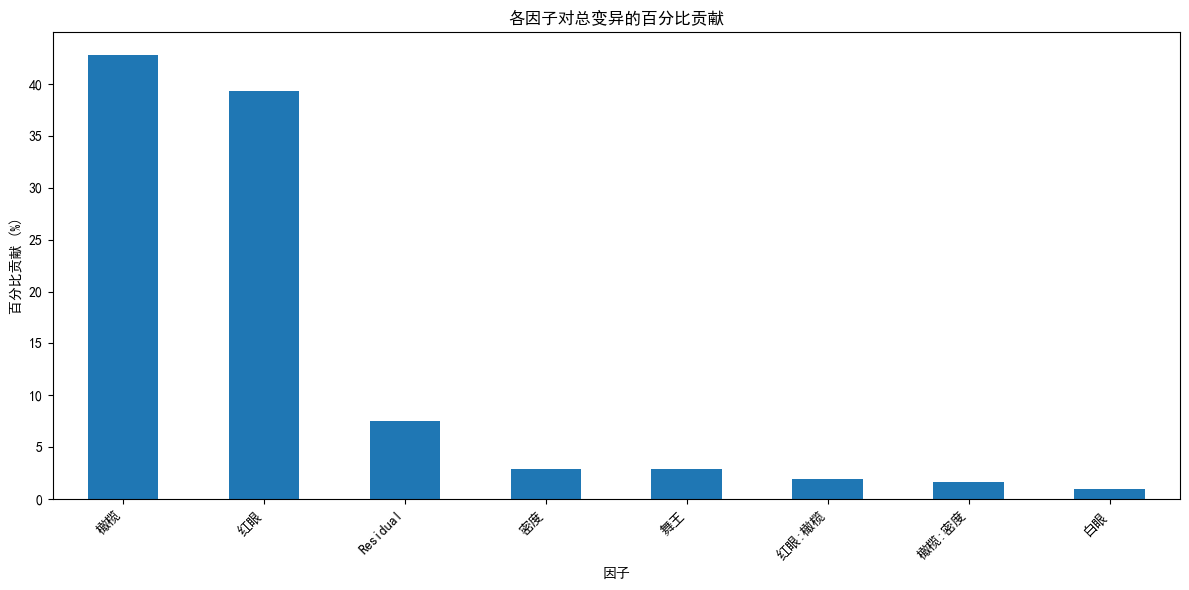

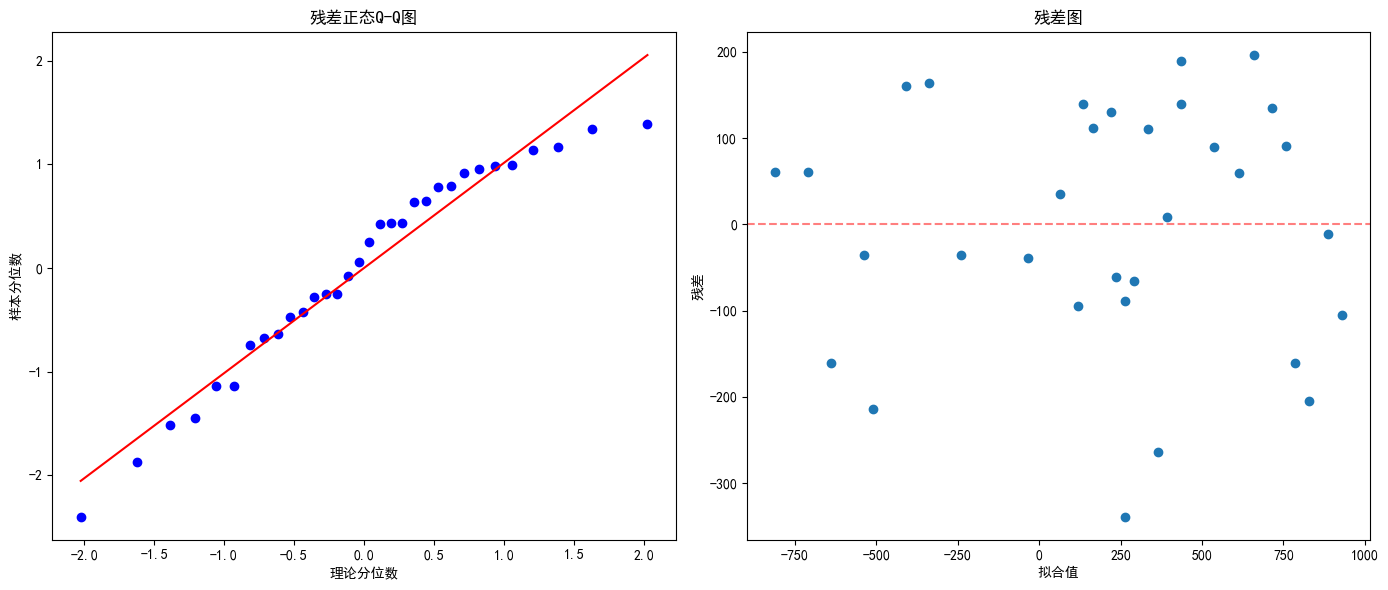

In [51]:
model = OLS_factor_DIY_model (df,[
    '红眼', 
    '橄榄',
    
    '白眼', 
    
    '密度',
    
    '舞王', 
    
    # '撑杆', 
],[
    '红眼:橄榄',
    
    
    '橄榄:密度',
    
    # '橄榄:舞王',

    # '红眼:撑杆',
    # '红眼:舞王',
    # '橄榄:撑杆',
    # '红眼:密度',

    # '红眼:白眼',
    # '橄榄:白眼',
])

In [52]:
pd.DataFrame(model.params)

,0
Intercept,193.7500
红眼,-317.5000
橄榄,-331.2500
白眼,50.0000
密度,-85.9375
舞王,-85.6250
红眼:橄榄,-70.0000
橄榄:密度,-64.0625


In [53]:
df

,Y,路障,撑杆,铁桶,读报,铁门,橄榄,舞王,潜水,冰车,...,矿工,跳跳,蹦极,扶梯,投篮,白眼,红眼,密度,residuals,fitted
0,-175,1,-1,1,-1,-1,1,-1,-1,-1,...,1,1,1,1,-1,-1,1,-1,164.375,-339.375
1,175,1,-1,1,-1,-1,1,1,-1,-1,...,1,1,1,-1,-1,-1,-1,-1,-89.375,264.375
2,-725,1,1,-1,1,-1,1,1,-1,-1,...,-1,-1,1,1,1,-1,1,-1,-214.375,-510.625
3,100,1,-1,-1,-1,-1,1,1,-1,-1,...,1,1,1,1,-1,1,-1,1,35.625,64.375
4,825,1,1,1,-1,1,-1,-1,-1,-1,...,1,1,1,1,-1,1,-1,-1,-105.000,930.000
5,625,1,-1,-1,1,1,1,-1,-1,-1,...,1,-1,1,1,1,1,-1,-1,89.375,535.625
6,850,1,-1,-1,-1,1,-1,1,-1,-1,...,1,-1,1,1,-1,1,-1,-1,91.250,758.750
7,275,1,-1,-1,1,1,-1,1,-1,-1,...,-1,1,-1,-1,1,-1,1,-1,111.250,163.750
8,100,1,1,-1,-1,-1,1,1,-1,-1,...,1,-1,1,-1,-1,1,-1,-1,-264.375,364.375
9,-250,1,-1,1,1,-1,1,1,-1,-1,...,1,-1,1,-1,-1,1,1,-1,160.625,-410.625


In [54]:
model.predict(df).to_csv('2.1output.csv')

In [55]:
 (df,[
    '红眼', 
    '气球', 
    '橄榄',
    '投篮',
    '撑杆', 
    '舞王', 
    '白眼', 
],[
    '红眼:橄榄',
    
    '红眼:气球',
    '红眼:投篮',
    '红眼:撑杆',
    '红眼:舞王',
    '红眼:白眼',
    '红眼:密度',
    
    '橄榄:气球',
    '橄榄:投篮',
    '橄榄:撑杆',
    '橄榄:舞王',
    '橄榄:白眼',
    '橄榄:密度',
])

(      Y  路障  撑杆  铁桶  读报  铁门  橄榄  舞王  潜水  冰车  ...  矿工  跳跳  蹦极  扶梯  投篮  白眼  红眼  \
 0  -175   1  -1   1  -1  -1   1  -1  -1  -1  ...   1   1   1   1  -1  -1   1   
 1   175   1  -1   1  -1  -1   1   1  -1  -1  ...   1   1   1  -1  -1  -1  -1   
 2  -725   1   1  -1   1  -1   1   1  -1  -1  ...  -1  -1   1   1   1  -1   1   
 3   100   1  -1  -1  -1  -1   1   1  -1  -1  ...   1   1   1   1  -1   1  -1   
 4   825   1   1   1  -1   1  -1  -1  -1  -1  ...   1   1   1   1  -1   1  -1   
 5   625   1  -1  -1   1   1   1  -1  -1  -1  ...   1  -1   1   1   1   1  -1   
 6   850   1  -1  -1  -1   1  -1   1  -1  -1  ...   1  -1   1   1  -1   1  -1   
 7   275   1  -1  -1   1   1  -1   1  -1  -1  ...  -1   1  -1  -1   1  -1   1   
 8   100   1   1  -1  -1  -1   1   1  -1  -1  ...   1  -1   1  -1  -1   1  -1   
 9  -250   1  -1   1   1  -1   1   1  -1  -1  ...   1  -1   1  -1  -1   1   1   
 10  875   1  -1  -1   1  -1  -1  -1  -1  -1  ...   1   1   1   1   1   1  -1   
 11  350   1  -1  -1   1  -1